# 阶段四：逻辑回归基线 / Stage 4: Logistic Regression Baseline

本 Notebook 使用固定的 60%/20%/20% 分层随机切分，比较总体违约率虚拟基线、无权重逻辑回归和类别平衡逻辑回归。测试集不是 OOT，固定阈值 `0.5` 也不是业务审批阈值。

This notebook uses the fixed 60%/20%/20% stratified random split to compare the prior-probability dummy, unweighted logistic regression, and class-balanced logistic regression. The test set is not OOT, and the fixed `0.5` threshold is not a business approval threshold.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from credit_risk.data import RAW_XLS_NAME, load_dataset
from credit_risk.experiment import (
    MODEL_NAMES_EN,
    format_model_report,
    generate_model_figures,
    run_baseline_experiment,
)

In [2]:
data_path = PROJECT_ROOT / 'data' / 'raw' / RAW_XLS_NAME
frame = load_dataset(data_path)
result = run_baseline_experiment(frame)

report_path = PROJECT_ROOT / 'reports' / 'model_report.md'
figure_directory = PROJECT_ROOT / 'reports' / 'figures'
figure_paths = generate_model_figures(result, figure_directory)
report_path.write_text(format_model_report(result), encoding='utf-8')
print(f'Report / 报告: {report_path.relative_to(PROJECT_ROOT)}')
print('The test set is a stratified random holdout, not OOT. / 测试集是分层随机留出集，不是 OOT。')

Report / 报告: reports\model_report.md
The test set is a stratified random holdout, not OOT. / 测试集是分层随机留出集，不是 OOT。


In [3]:
def metrics_frame(split):
    rows = []
    for name, metrics in result.metrics[split].items():
        rows.append({
            'model': MODEL_NAMES_EN[name],
            'ROC-AUC': metrics['roc_auc'],
            'PR-AUC': metrics['pr_auc'],
            'KS': metrics['ks'],
            'Brier Score': metrics['brier_score'],
            'Precision @ 0.5': metrics['precision'],
            'Recall @ 0.5': metrics['recall'],
        })
    return pd.DataFrame(rows).set_index('model')

print('Validation / 验证集')
display(metrics_frame('validation'))
print('Frozen test / 冻结测试集')
display(metrics_frame('test'))

Validation / 验证集


,ROC-AUC,PR-AUC,KS,Brier Score,Precision @ 0.5,Recall @ 0.5
model,,,,,,
Prior-probability dummy,0.500000,0.221167,0.000000,0.172252,0.000000,0.000000
Unweighted logistic regression,0.762873,0.537176,0.415618,0.136816,0.687593,0.346647
Class-balanced logistic regression,0.762728,0.536580,0.419274,0.183247,0.497379,0.571967


Frozen test / 冻结测试集


,ROC-AUC,PR-AUC,KS,Brier Score,Precision @ 0.5,Recall @ 0.5
model,,,,,,
Prior-probability dummy,0.500000,0.221167,0.000000,0.172252,0.000000,0.000000
Unweighted logistic regression,0.759050,0.525794,0.396967,0.138774,0.666191,0.351922
Class-balanced logistic regression,0.758999,0.522564,0.394632,0.185748,0.484808,0.553127


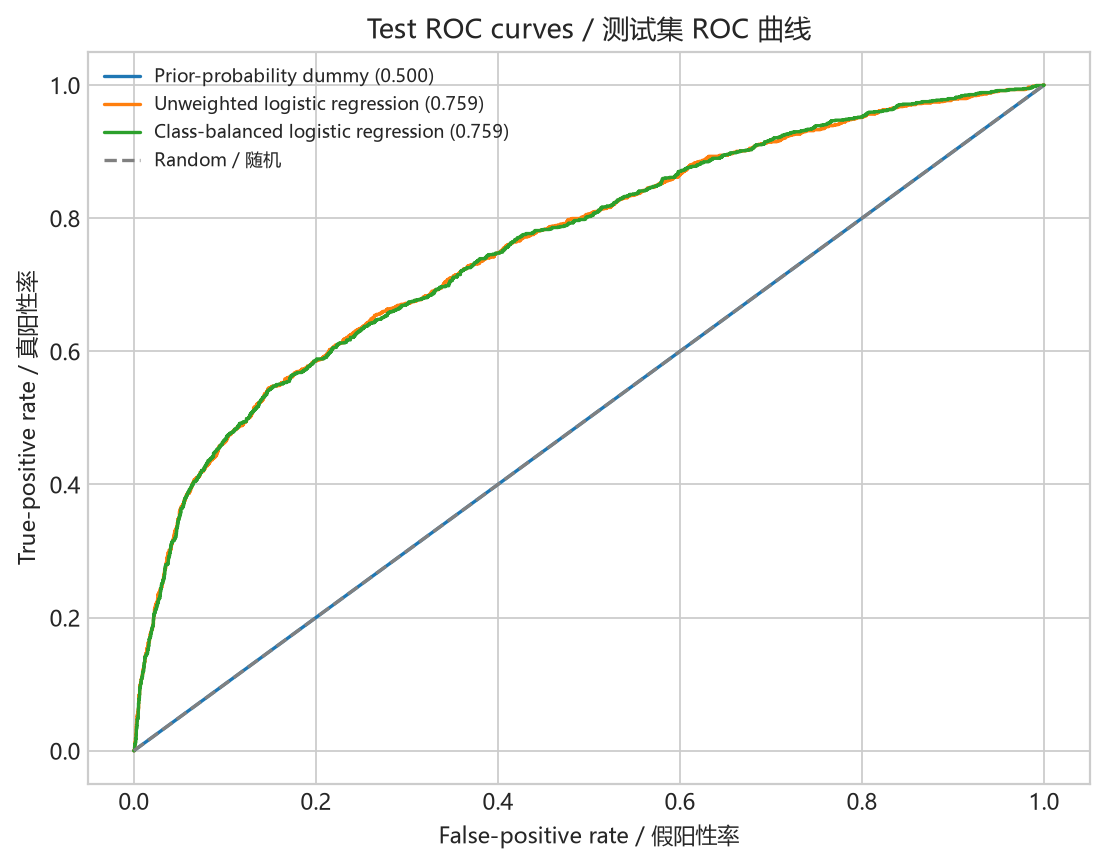

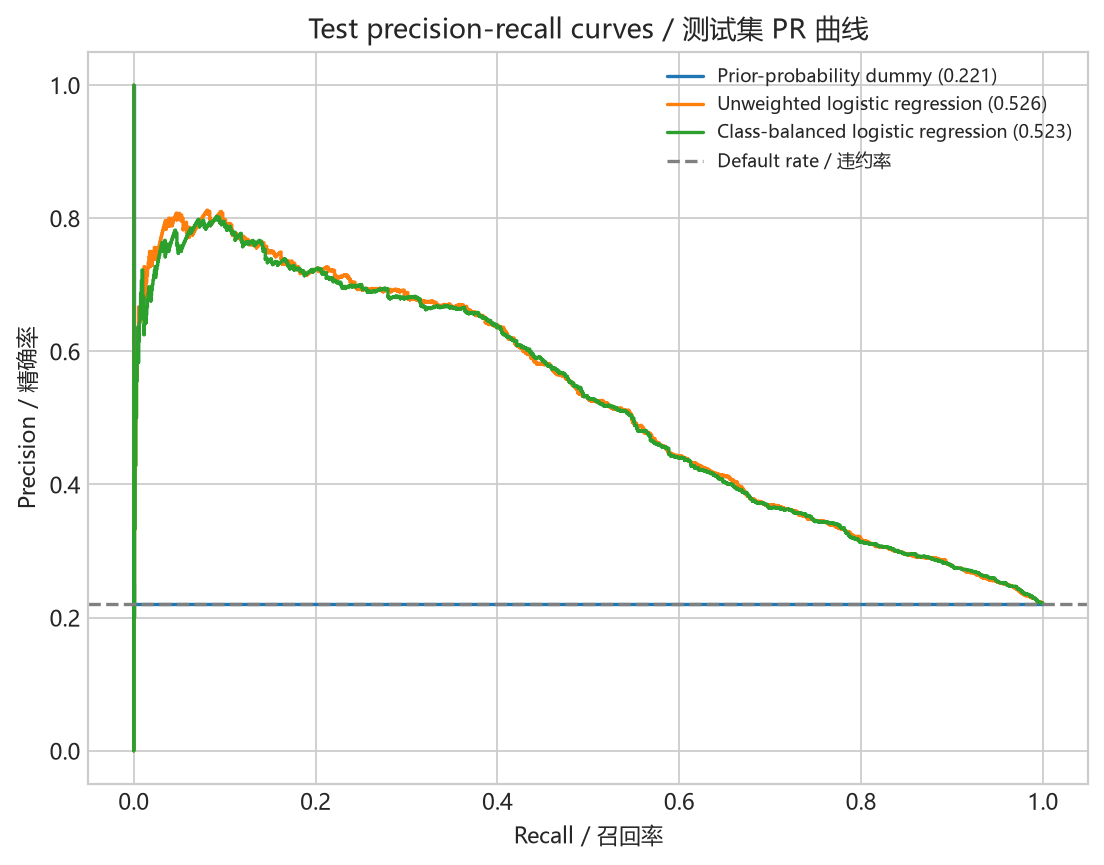

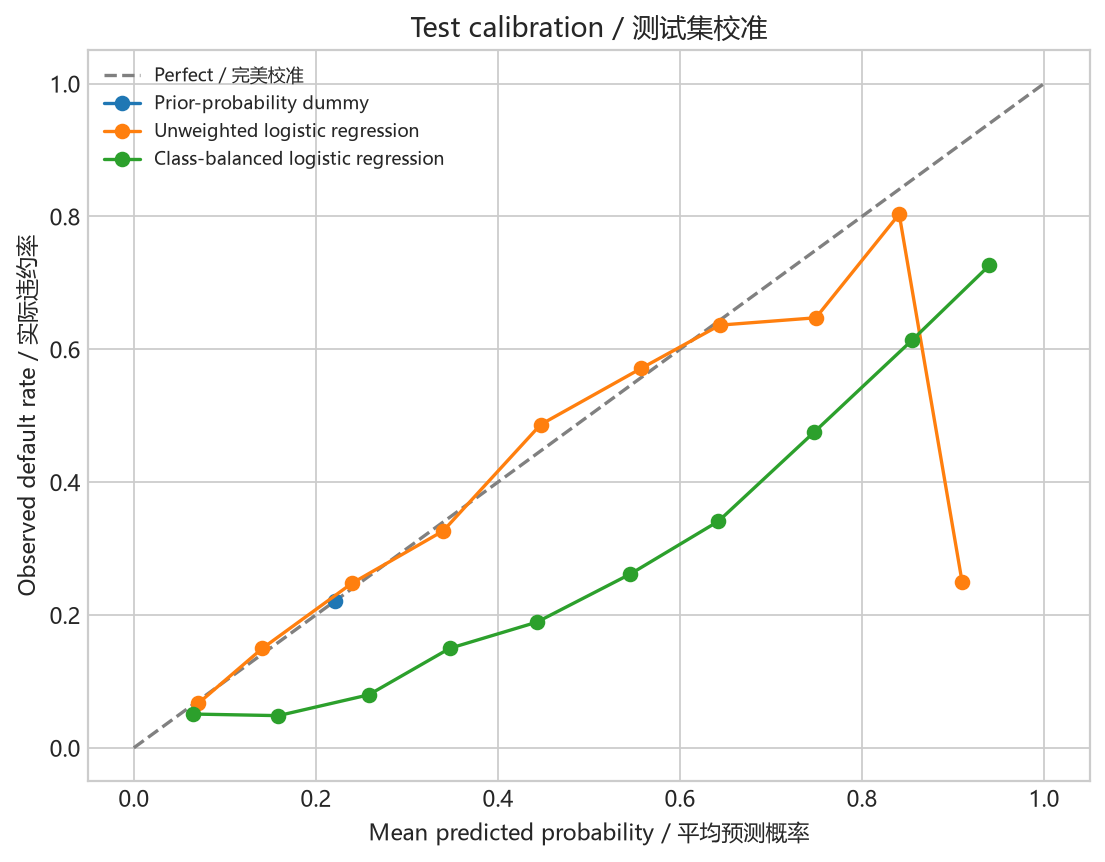

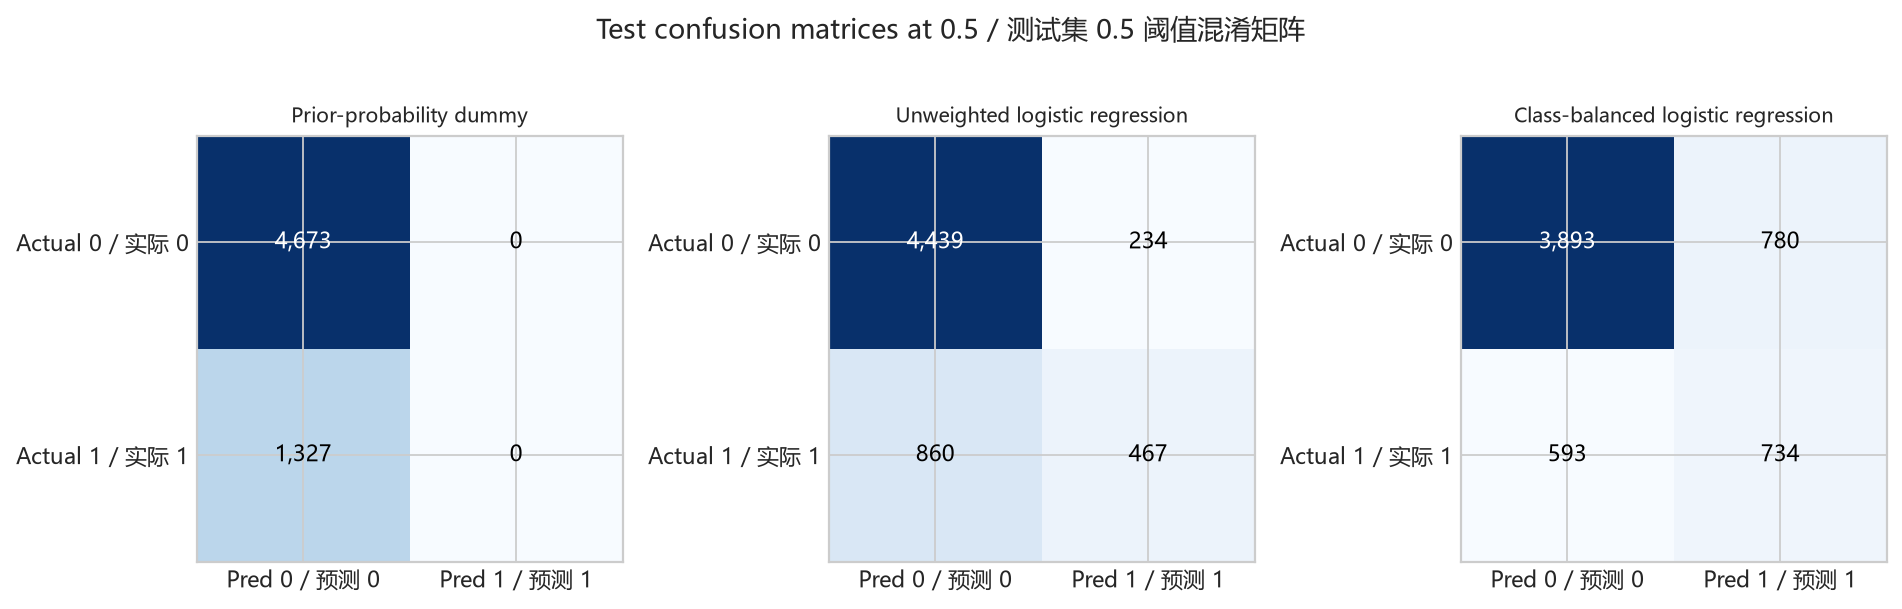

In [4]:
display(Image(filename=str(figure_directory / 'model_roc_curves.png')))
display(Image(filename=str(figure_directory / 'model_pr_curves.png')))
display(Image(filename=str(figure_directory / 'model_calibration.png')))
display(Image(filename=str(figure_directory / 'model_confusion_matrices.png')))